=== ЛАБ. РОБОТА 6: АНСАМБЛЕВІ МОДЕЛІ (Water Quality) ===

Датасет 'Water Potability' успішно завантажено!
Кількість записів після очищення від пропусків: 2011

--- 1. RANDOM FOREST CLASSIFIER ---
Accuracy (Точність) Random Forest: 0.6623


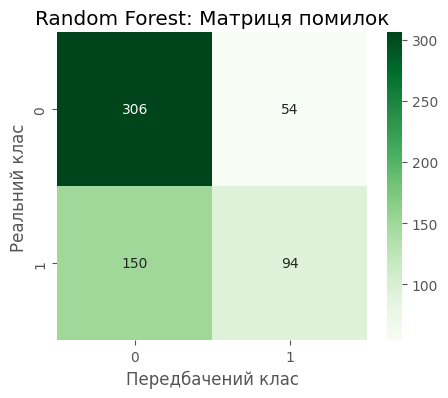


--- 2. GRADIENT BOOSTING CLASSIFIER ---
Accuracy (Точність) Gradient Boosting: 0.6374

--- ПОРІВНЯННЯ ВАЖЛИВОСТІ ОЗНАК ---
            Ознака  Важливість (Random Forest)  Важливість (Grad Boosting)
4          Sulfate                    0.153827                    0.212265
0               ph                    0.138255                    0.249294
2           Solids                    0.117258                    0.111565
1         Hardness                    0.113502                    0.107429
3      Chloramines                    0.111609                    0.106980
6   Organic_carbon                    0.094267                    0.057668
7  Trihalomethanes                    0.093999                    0.075464
8        Turbidity                    0.090263                    0.035655
5     Conductivity                    0.087020                    0.043680


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Імпортуємо ансамблеві моделі та метрики [cite: 1378-1379]
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Налаштування виводу графіків
%matplotlib inline
plt.style.use('ggplot')

print("=== ЛАБ. РОБОТА 6: АНСАМБЛЕВІ МОДЕЛІ (Water Quality) ===\n")

# 1. Завантаження даних
try:
    df = pd.read_csv('water_potability.csv')
    print("Датасет 'Water Potability' успішно завантажено!")
except FileNotFoundError:
    print("Помилка: Файл 'water_potability.csv' не знайдено.")

# 2. Попередня обробка даних
# Оскільки в хімічних аналізах можуть бути пропуски (NaN), ми їх видаляємо для коректної роботи моделей
df = df.dropna()
print(f"Кількість записів після очищення від пропусків: {df.shape[0]}\n")

# Відділяємо ознаки (X) та цільову змінну (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

# 3. Розбиття на тренувальну та тестову вибірки [cite: 1381-1383]
# stratify=y зберігає пропорцію придатної/непридатної води у вибірках [cite: 1386-1387]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# ==========================================
# ЧАСТИНА 1: ВИПАДКОВИЙ ЛІС (Random Forest)
# ==========================================
print("--- 1. RANDOM FOREST CLASSIFIER ---")

# Ініціалізація та навчання моделі (100 дерев) [cite: 1379-1380]
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Прогнозування та оцінка [cite: 1390-1391]
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Accuracy (Точність) Random Forest: {rf_accuracy:.4f}")

# Матриця помилок [cite: 1392-1395]
plt.figure(figsize=(5, 4))
rf_conf_matrix = confusion_matrix(y_test, rf_predictions)
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest: Матриця помилок')
plt.xlabel('Передбачений клас')
plt.ylabel('Реальний клас')
plt.show()

# ==========================================
# ЧАСТИНА 2: ГРАДІЄНТНИЙ БУСТІНГ (Gradient Boosting)
# ==========================================
print("\n--- 2. GRADIENT BOOSTING CLASSIFIER ---")

# Градієнтний бустінг виправляє помилки попередніх дерев [cite: 1348-1350]
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train) # [cite: 1414-1416]

# Оцінка [cite: 1417]
gb_predictions = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_predictions)
print(f"Accuracy (Точність) Gradient Boosting: {gb_accuracy:.4f}")

# ==========================================
# ЧАСТИНА 3: АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК
# ==========================================
print("\n--- ПОРІВНЯННЯ ВАЖЛИВОСТІ ОЗНАК ---")
# Обидва алгоритми дозволяють визначити, які ознаки найважливіші [cite: 1398-1400, 1418-1420]
feature_importance_df = pd.DataFrame({
    'Ознака': X.columns,
    'Важливість (Random Forest)': rf_model.feature_importances_,
    'Важливість (Grad Boosting)': gb_model.feature_importances_
}).sort_values(by='Важливість (Random Forest)', ascending=False)

print(feature_importance_df)